# Data Understanding

## 2.1 Sumber Data

Dataset **ECG200** diambil dari repositori [Time Series Classification](https://www.timeseriesclassification.com/dataset.php), yang menyediakan kumpulan data time series untuk keperluan *benchmarking* klasifikasi. Meskipun halaman saat ini mengalami kendala tampilan (menampilkan *"No matching records found"*), dataset ECG200 tetap tersedia secara publik melalui arsip UCR/UEA dan telah digunakan secara luas dalam literatur *time series classification*.

### Asal dan Cara Pengambilan Data
- **Asal data**: Dataset ini diformat oleh **R. Olszewski** sebagai bagian dari tesis doktoralnya di Carnegie Mellon University tahun **2001**.
- **Sumber sinyal**: Setiap sampel mewakili satu denyut jantung, direkam dari aktivitas listrik jantung pasien menggunakan sistem perekaman ECG klinis.
- **Alat yang digunakan**: Rekaman ECG diperoleh menggunakan **perangkat elektrokardiografi medis standar**, yang terdiri dari:
  - **Elektroda permukaan** yang ditempelkan pada dada dan anggota tubuh pasien,
  - **Amplifier sinyal** untuk memperkuat sinyal bioelektrik yang lemah,
  - **Analog-to-Digital Converter (ADC)** untuk mengubah sinyal analog menjadi data digital berupa deret waktu.
- **Proses pengambilan**:  
  - Sinyal ECG mentah direkam selama sesi klinis,  
  - Segmen yang merepresentasikan **satu siklus denyut jantung lengkap** dipilih secara manual oleh ahli,  
  - Segmen tersebut kemudian dipotong, dinormalisasi, dan diberi label berdasarkan diagnosis klinis pasien.
- **Waktu pengambilan asli**: Data dikumpulkan sebelum atau selama penelitian tesis (sekitar awal 2000-an).
- **Format data**: Disimpan dalam format **ARFF** (*Attribute-Relation File Format*), sesuai standar WEKA.
- **Preprocessing oleh penyedia**:  
  - Setiap sampel mewakili satu denyut jantung, dengan panjang tetap **96 titik waktu**.  
  - Dinormalisasi secara global.  
  - Label: **`1` (normal heartbeat)** dan **`-1` (Myocardial Infarction / Ischemia)**.

### Komposisi Dataset
- **Data latih**: 100 sampel  
- **Data uji**: 100 sampel  
- **Jumlah fitur per sampel**: 96 (time steps)  
- **Jumlah kelas**: 2 (normal vs. infark miokard)  
- **Dimensi**: Univariat (1 dimensi)

## 2.2 Eksplorasi Data
### 2.2.1 Import Library dan Muat Data

In [ ]:
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

train_path = 'ECG200/ECG200_TRAIN.arff'
test_path = 'ECG200/ECG200_TEST.arff'

data_train, _ = arff.loadarff(train_path)
data_test, _ = arff.loadarff(test_path)

df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)

df_train['target'] = df_train['target'].apply(lambda x: int(x.decode('utf-8')))
df_test['target'] = df_test['target'].apply(lambda x: int(x.decode('utf-8')))

print("✅ Data berhasil dimuat dan label telah dikonversi ke integer.")

✅ Data berhasil dimuat dan label telah dikonversi ke integer.


### 2.2.2 Struktur Kolom dan Informasi Dataset

In [ ]:
print("=== Struktur Kolom ===")
print(df_train.columns.tolist())

print("\n=== Informasi Dataset Latih ===")
df_train.info()

print("\n=== Statistik Deskriptif ===")
df_train.describe().T.head(10) 

=== Struktur Kolom ===
['att1', 'att2', 'att3', 'att4', 'att5', 'att6', 'att7', 'att8', 'att9', 'att10', 'att11', 'att12', 'att13', 'att14', 'att15', 'att16', 'att17', 'att18', 'att19', 'att20', 'att21', 'att22', 'att23', 'att24', 'att25', 'att26', 'att27', 'att28', 'att29', 'att30', 'att31', 'att32', 'att33', 'att34', 'att35', 'att36', 'att37', 'att38', 'att39', 'att40', 'att41', 'att42', 'att43', 'att44', 'att45', 'att46', 'att47', 'att48', 'att49', 'att50', 'att51', 'att52', 'att53', 'att54', 'att55', 'att56', 'att57', 'att58', 'att59', 'att60', 'att61', 'att62', 'att63', 'att64', 'att65', 'att66', 'att67', 'att68', 'att69', 'att70', 'att71', 'att72', 'att73', 'att74', 'att75', 'att76', 'att77', 'att78', 'att79', 'att80', 'att81', 'att82', 'att83', 'att84', 'att85', 'att86', 'att87', 'att88', 'att89', 'att90', 'att91', 'att92', 'att93', 'att94', 'att95', 'att96', 'target']

=== Informasi Dataset Latih ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data co

,count,mean,std,min,25%,50%,75%,max
att1,100.0,0.708438,0.593513,-0.706305,0.318643,0.581008,0.994760,2.689017
att2,100.0,1.422151,0.927972,-1.100715,0.779810,1.232191,2.093703,3.535038
att3,100.0,2.039149,1.046880,-1.321589,1.525548,2.152552,2.707411,3.850263
att4,100.0,2.126455,1.098754,-1.076313,1.511639,2.234408,2.865394,4.199145
att5,100.0,1.551616,0.954734,-1.247922,0.966292,1.746861,2.163355,3.720899
att6,100.0,0.762251,0.963111,-1.482391,0.022470,0.574297,1.502335,3.026452
att7,100.0,0.282647,1.096712,-1.598712,-0.603378,0.120230,1.226563,2.454195
att8,100.0,0.333630,0.877640,-1.508060,-0.464767,0.366122,1.008876,2.220327
att9,100.0,0.372973,0.761753,-1.609777,-0.075355,0.457255,0.990675,2.122435
att10,100.0,0.210769,0.739185,-1.600454,-0.205867,0.182365,0.776566,1.916524


### 2.2.3 Identifikasi Missing Value

=== Jumlah Missing Value ===
Data Latih:
Tidak ada missing value.

Data Uji:
Tidak ada missing value.


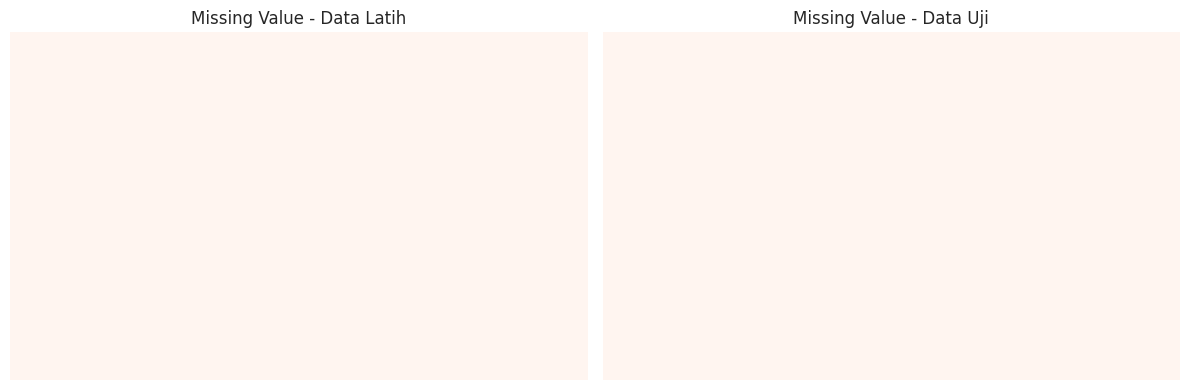

In [ ]:
print("=== Jumlah Missing Value ===")
missing_train = df_train.isnull().sum()
missing_test = df_test.isnull().sum()

print("Data Latih:")
if missing_train.sum() == 0:
    print("Tidak ada missing value.")
else:
    print(missing_train[missing_train > 0])

print("\nData Uji:")
if missing_test.sum() == 0:
    print("Tidak ada missing value.")
else:
    print(missing_test[missing_test > 0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap hanya menunjukkan keberadaan missing (True = putih/merah, False = putih)
sns.heatmap(df_train.isnull(), cbar=False, cmap='Reds', ax=ax[0], yticklabels=False, xticklabels=False)
ax[0].set_title('Missing Value - Data Latih', fontsize=12)
ax[0].set_facecolor('white')

sns.heatmap(df_test.isnull(), cbar=False, cmap='Reds', ax=ax[1], yticklabels=False, xticklabels=False)
ax[1].set_title('Missing Value - Data Uji', fontsize=12)
ax[1].set_facecolor('white')

fig.patch.set_facecolor('white')
for a in ax:
    a.figure.set_facecolor('white')

plt.tight_layout()
plt.show()

### 2.2.4 Distribusi Kelas

=== Distribusi Kelas ===
Data Latih:
target
-1    31
 1    69
Name: count, dtype: int64

Data Uji:
target
-1    36
 1    64
Name: count, dtype: int64


/tmp/ipykernel_17518/1495402320.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='target', ax=ax[0], palette='pastel')
/tmp/ipykernel_17518/1495402320.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_test, x='target', ax=ax[1], palette='pastel')


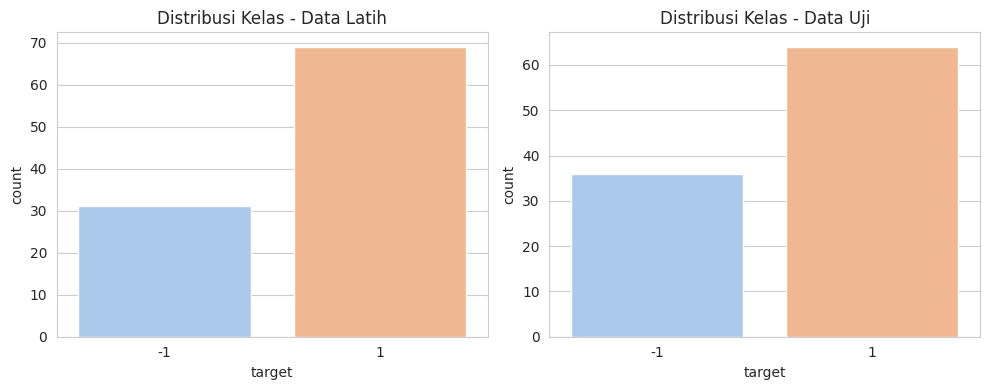

In [ ]:
print("=== Distribusi Kelas ===")
print("Data Latih:")
print(df_train['target'].value_counts().sort_index())

print("\nData Uji:")
print(df_test['target'].value_counts().sort_index())


fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df_train, x='target', ax=ax[0], palette='pastel')
ax[0].set_title('Distribusi Kelas - Data Latih')

sns.countplot(data=df_test, x='target', ax=ax[1], palette='pastel')
ax[1].set_title('Distribusi Kelas - Data Uji')

plt.tight_layout()
plt.show()

### 2.2.5 Visualisasi Time Series Contoh Per Kelas

Jumlah sampel normal: 69
Jumlah sampel abnormal: 31


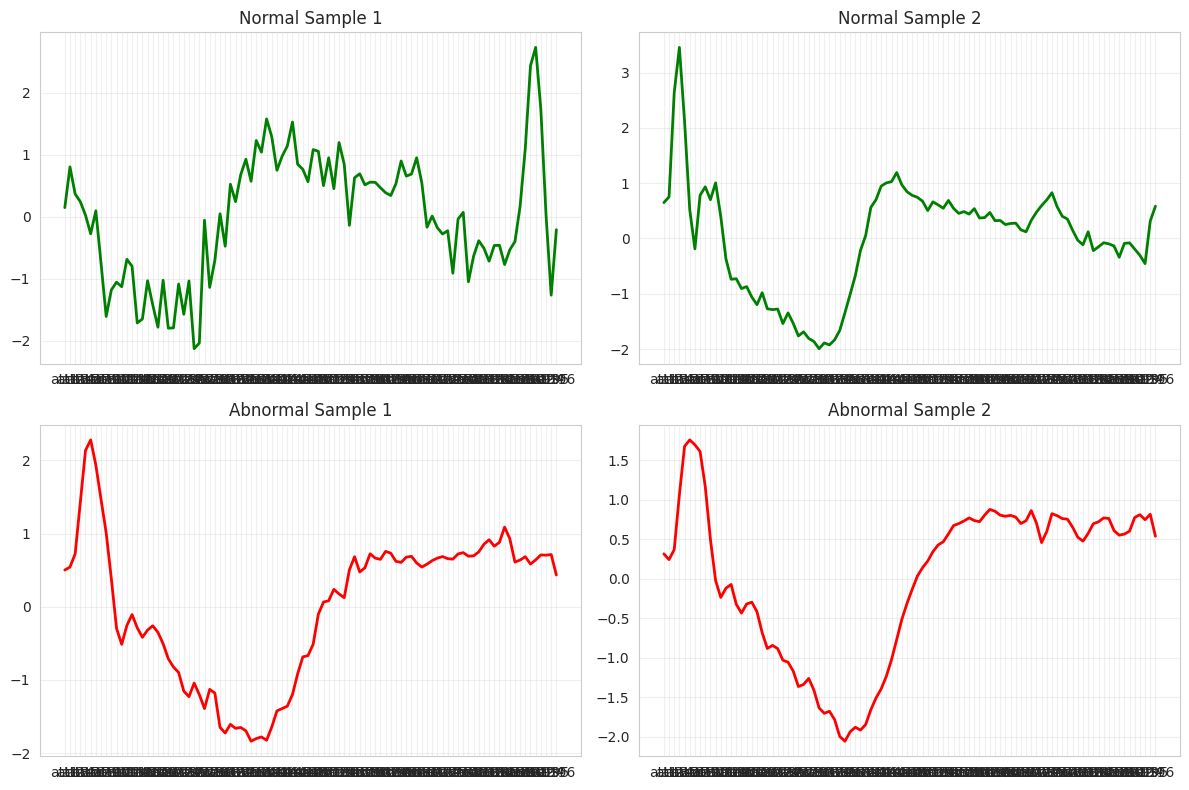

In [ ]:
print("Jumlah sampel normal:", len(df_train[df_train['target'] == 1]))
print("Jumlah sampel abnormal:", len(df_train[df_train['target'] == -1]))

if len(df_train[df_train['target'] == 1]) == 0 or len(df_train[df_train['target'] == -1]) == 0:
    print("⚠️ Peringatan: Tidak ada data ditemukan untuk salah satu kelas!")
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    sample_normal = df_train[df_train['target'] == 1].iloc[:2]
    sample_abnormal = df_train[df_train['target'] == -1].iloc[:2]

    for i, row in enumerate(sample_normal.iterrows()):
        idx, data = row
        axes[i].plot(data[:-1], color='green', linewidth=2)
        axes[i].set_title(f'Normal Sample {i+1}')
        axes[i].grid(True, alpha=0.3)

    for i, row in enumerate(sample_abnormal.iterrows()):
        idx, data = row
        axes[i+2].plot(data[:-1], color='red', linewidth=2)
        axes[i+2].set_title(f'Abnormal Sample {i+1}')
        axes[i+2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### 2.2.6 Deteksi Outlier Menggunakan ABOD (Angle-Based Outlier Detection)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function fit_predict is deprecated
  warnings.warn(msg, category=FutureWarning)


🔍 Jumlah outlier terdeteksi: 0 dari 200 sampel
⚠️ Tidak ada outlier terdeteksi — hanya menampilkan sampel normal.


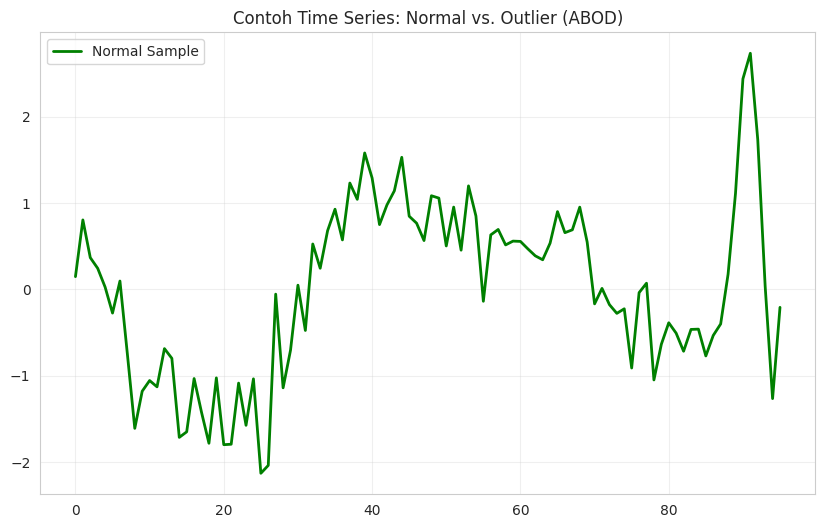

In [ ]:
from pyod.models.abod import ABOD

df_combined = pd.concat([df_train, df_test], ignore_index=True)

X = df_combined.iloc[:, :-1].values 
y = df_combined['target'].values

abod = ABOD(contamination=0.05)  
outlier_labels = abod.fit_predict(X)

df_combined['outlier'] = outlier_labels

n_outliers = (outlier_labels == -1).sum()
print(f"🔍 Jumlah outlier terdeteksi: {n_outliers} dari {len(df_combined)} sampel")

fig, ax = plt.subplots(figsize=(10, 6))

normal_sample = df_combined[df_combined['outlier'] == 1].iloc[0, :-2].values
ax.plot(normal_sample, color='green', label='Normal Sample', linewidth=2)

if n_outliers > 0:
    outlier_sample = df_combined[df_combined['outlier'] == -1].iloc[0, :-2].values
    ax.plot(outlier_sample, color='red', label='Detected Outlier', linewidth=2, linestyle='--')
else:
    print("⚠️ Tidak ada outlier terdeteksi — hanya menampilkan sampel normal.")

ax.set_title('Contoh Time Series: Normal vs. Outlier (ABOD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 2.3 Relevansi terhadap Tujuan Analisis

Dataset ini relevan karena:

- **Mewakili masalah nyata**: Deteksi infark miokard dari sinyal ECG merupakan aplikasi klinis penting dalam diagnosis jantung.
- **Ukuran kecil namun representatif**: Cocok untuk eksperimen awal dalam klasifikasi time series tanpa memerlukan sumber daya besar.
- **Struktur sederhana**: Data univariat dan panjang tetap mempermudah implementasi model (misalnya: Random Forest, 1D-CNN, atau ekstraksi fitur statistik).
- **Siap untuk demonstrasi**: Format dan ukuran dataset memungkinkan integrasi ke dalam aplikasi berbasis **Streamlit** sebagai demo prediksi real-time atau batch.